In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/e-commerce-customer-behavior-dataset/E-commerce Customer Behavior - Sheet1.csv


In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [3]:

url = '/kaggle/input/e-commerce-customer-behavior-dataset/E-commerce Customer Behavior - Sheet1.csv'  # Replace with your actual dataset link
ecom_data = pd.read_csv(url)


In [4]:
print("Dataset Overview:")
print(ecom_data.info())

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB
None


In [5]:
print("\nFirst Few Rows of the Dataset:")
print(ecom_data.head())


First Few Rows of the Dataset:
   Customer ID  Gender  Age           City Membership Type  Total Spend  \
0          101  Female   29       New York            Gold      1120.20   
1          102    Male   34    Los Angeles          Silver       780.50   
2          103  Female   43        Chicago          Bronze       510.75   
3          104    Male   30  San Francisco            Gold      1480.30   
4          105    Male   27          Miami          Silver       720.40   

   Items Purchased  Average Rating  Discount Applied  \
0               14             4.6              True   
1               11             4.1             False   
2                9             3.4              True   
3               19             4.7             False   
4               13             4.0              True   

   Days Since Last Purchase Satisfaction Level  
0                        25          Satisfied  
1                        18            Neutral  
2                        42      

In [6]:
print("\nSummary Statistics:")
print(ecom_data.describe())


Summary Statistics:
       Customer ID         Age  Total Spend  Items Purchased  Average Rating  \
count   350.000000  350.000000   350.000000       350.000000      350.000000   
mean    275.500000   33.597143   845.381714        12.600000        4.019143   
std     101.180532    4.870882   362.058695         4.155984        0.580539   
min     101.000000   26.000000   410.800000         7.000000        3.000000   
25%     188.250000   30.000000   502.000000         9.000000        3.500000   
50%     275.500000   32.500000   775.200000        12.000000        4.100000   
75%     362.750000   37.000000  1160.600000        15.000000        4.500000   
max     450.000000   43.000000  1520.100000        21.000000        4.900000   

       Days Since Last Purchase  
count                350.000000  
mean                  26.588571  
std                   13.440813  
min                    9.000000  
25%                   15.000000  
50%                   23.000000  
75%                 

In [7]:
ecom_data = ecom_data.drop_duplicates()


In [8]:
# Handling NaN values for numeric columns
numeric_columns = ecom_data.select_dtypes(include=['number']).columns
ecom_data[numeric_columns] = ecom_data[numeric_columns].fillna(ecom_data[numeric_columns].mean())

# fill with a placeholder like 'Unknown' for categorical columns
categorical_columns = ecom_data.select_dtypes(exclude=['number']).columns
ecom_data[categorical_columns] = ecom_data[categorical_columns].fillna('Unknown')


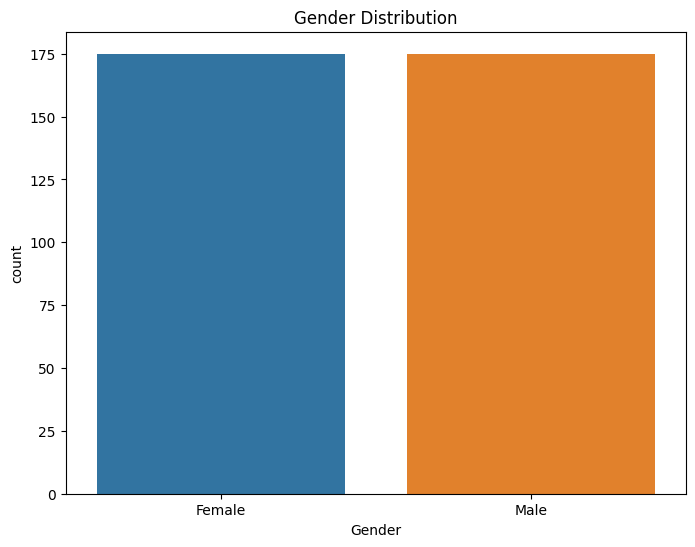

In [9]:
#Gender Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Gender', data=ecom_data)
plt.title('Gender Distribution')
plt.show()

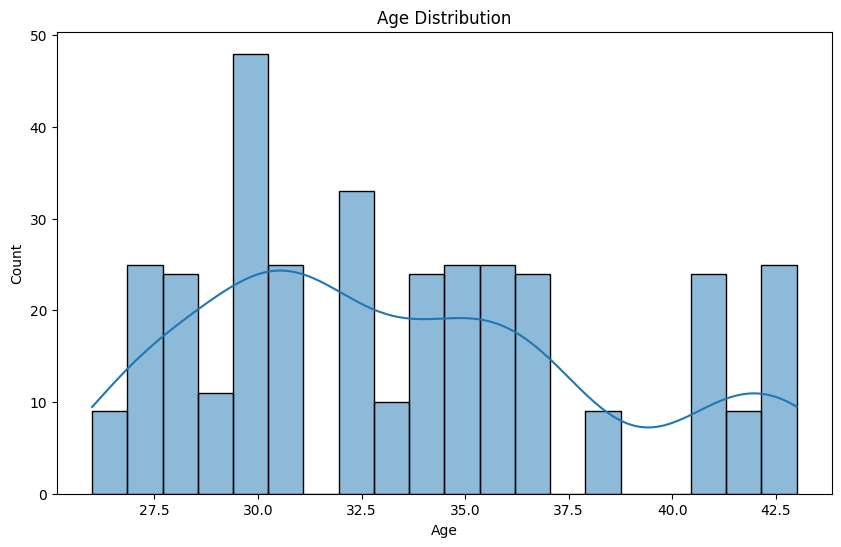

In [10]:

# Data Exploration - Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(ecom_data['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()


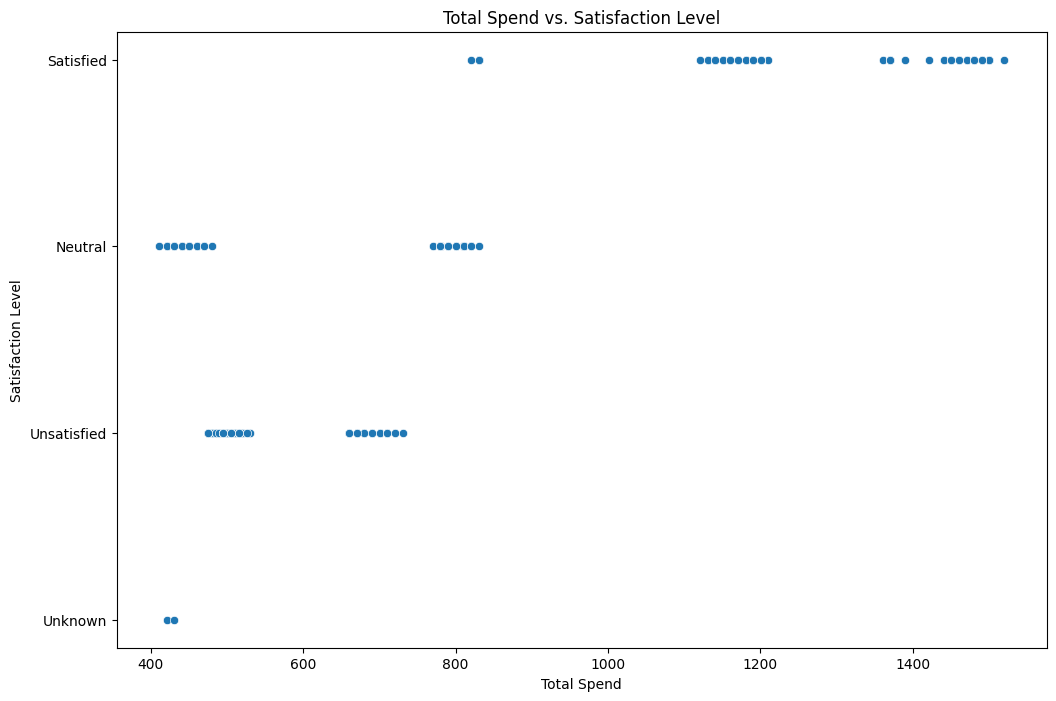

In [11]:
#Data Exploration - Total Spend vs. Satisfaction Level
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Total Spend', y='Satisfaction Level', data=ecom_data)
plt.title('Total Spend vs. Satisfaction Level')
plt.xlabel('Total Spend')
plt.ylabel('Satisfaction Level')
plt.show()

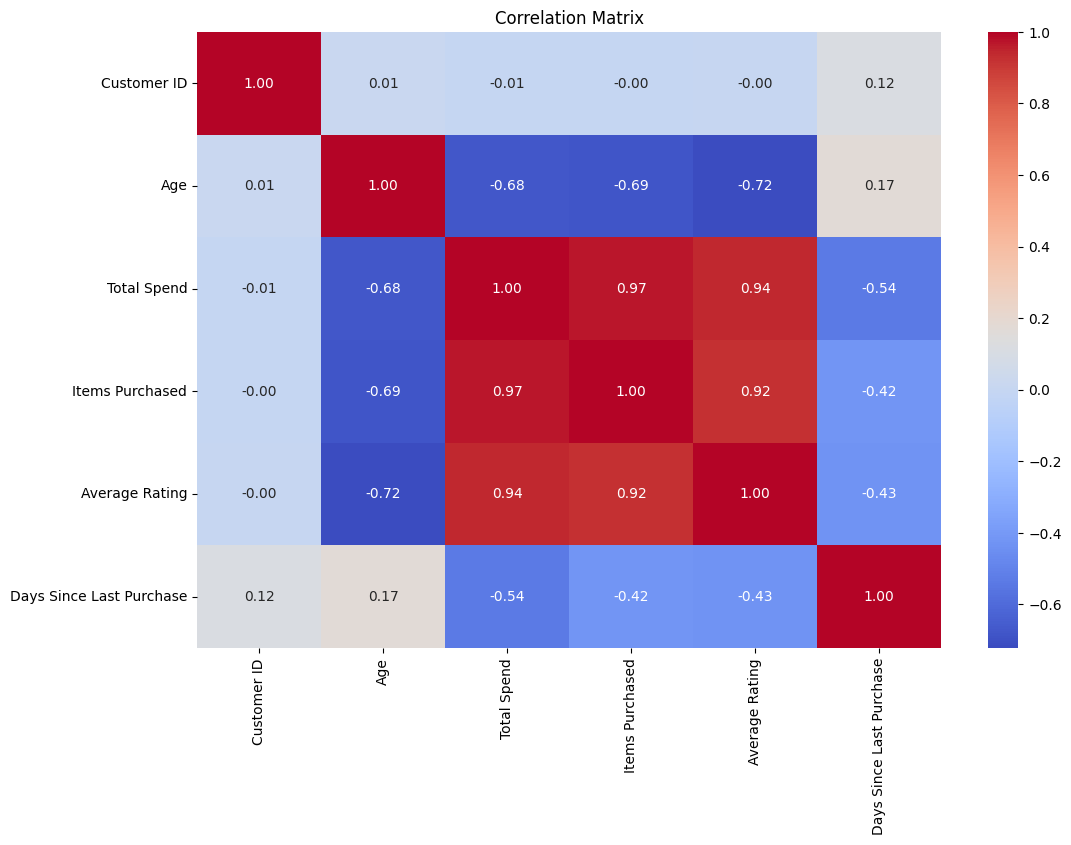

In [12]:
# Correlation Matrix
numeric_columns = ecom_data.select_dtypes(include='number')
correlation_matrix = numeric_columns.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


In [13]:

##Feature selection and target variable
features = ['Age', 'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied', 'Days Since Last Purchase']
target = 'Satisfaction Level'

X = ecom_data[features]
y = ecom_data[target]


In [14]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [15]:
from sklearn.preprocessing import LabelEncoder

# Create an instance of LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the target variable
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.fit_transform(y_test)

In [16]:
# Model training
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train_encoded)

RandomForestRegressor(random_state=42)

In [17]:
#Model evaluation
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test_encoded, y_pred)
r2 = r2_score(y_test_encoded, y_pred)

print(f"\nMean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")



Mean Squared Error: 0.2640
R-squared: 0.5452


In [18]:
import joblib
#Save the model (optional)
joblib.dump(model, 'ecommerce_model_rf.joblib')


['ecommerce_model_rf.joblib']